In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")


All libraries imported!


In [2]:
# Paths
DATASET_PATH = "data/raw/Crema"
OUTPUT_PATH = "data/processed"
MODEL_PATH = "models"
RESULTS_PATH = "results"

# Create output folders
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# Audio parameters
SAMPLE_RATE = 22050
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
TARGET_LENGTH = 87  # Around 2 seconds at 22050 Hz with hop_length=512

print(f"Dataset path: {DATASET_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Model path: {MODEL_PATH}")


Dataset path: data/raw/Crema
Output path: data/processed
Model path: models


In [3]:
# Find audio files
audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.m4a']
audio_files = []

for ext in audio_extensions:
    audio_files.extend(Path(DATASET_PATH).rglob(f'*{ext}'))

print(f"Found {len(audio_files)} audio files")

# Emotion mapping for CREMA-D
emotion_mapping = {
    'ANG': 'anger',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

def extract_emotion(filename):
    """Extract emotion from CREMA-D filename"""
    parts = filename.split('_')
    if len(parts) >= 3:
        emotion_code = parts[2]
        return emotion_mapping.get(emotion_code, 'unknown')
    return 'unknown'

# Create manifest
manifest = []
for audio_file in audio_files:
    emotion = extract_emotion(audio_file.name)
    manifest.append({
        'file_path': str(audio_file),
        'emotion': emotion,
        'filename': audio_file.name,
    })

df_manifest = pd.DataFrame(manifest)
print(f"\n Emotion distribution:")
print(df_manifest['emotion'].value_counts())

Found 7442 audio files

 Emotion distribution:
emotion
anger      1271
disgust    1271
fear       1271
happy      1271
sad        1271
neutral    1087
Name: count, dtype: int64


In [4]:
print("Converting audio files to mel-spectrograms...")
print("="*70)

def audio_to_melspectrogram(file_path, sr=SAMPLE_RATE, n_mels=N_MELS,
                            n_fft=N_FFT, hop_length=HOP_LENGTH, target_length=TARGET_LENGTH):
    """Convert audio file to mel-spectrogram"""
    try:
        # Load audio
        y, sr_loaded = librosa.load(str(file_path), sr=sr)
        
        # Create mel-spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          n_fft=n_fft, hop_length=hop_length)
        
        # Convert to dB scale
        S_db = librosa.power_to_db(S, ref=np.max)
        
        # Pad or truncate to target length
        if S_db.shape[1] < target_length:
            # Pad with zeros
            pad_width = target_length - S_db.shape[1]
            S_db = np.pad(S_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            # Truncate
            S_db = S_db[:, :target_length]
        
        return S_db
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Convert all spectrograms and store
spectrograms = []
emotions = []

for i, row in df_manifest.iterrows():
    spec = audio_to_melspectrogram(row['file_path'])
    
    if spec is not None:
        spectrograms.append(spec)
        emotions.append(row['emotion'])
        
        if (i + 1) % 500 == 0:
            print(f"  Processed {i + 1}/{len(df_manifest)} files...")

print(f"\nSuccessfully converted {len(spectrograms)} spectrograms!")

# Convert to numpy arrays
X = np.array(spectrograms)
print(f"Spectrogram array shape: {X.shape}")
print(f"  (samples, mel_bands, time_steps)")

Converting audio files to mel-spectrograms...
  Processed 500/7442 files...
  Processed 1000/7442 files...
  Processed 1500/7442 files...
  Processed 2000/7442 files...
  Processed 2500/7442 files...
  Processed 3000/7442 files...
  Processed 3500/7442 files...
  Processed 4000/7442 files...
  Processed 4500/7442 files...
  Processed 5000/7442 files...
  Processed 5500/7442 files...
  Processed 6000/7442 files...
  Processed 6500/7442 files...
  Processed 7000/7442 files...

Successfully converted 7442 spectrograms!
Spectrogram array shape: (7442, 128, 87)
  (samples, mel_bands, time_steps)


In [5]:
# Encode emotions
le = LabelEncoder()
y = le.fit_transform(emotions)

print(f"Label encoding complete")
print(f"\nEmotion classes:")
for i, emotion in enumerate(le.classes_):
    count = np.sum(y == i)
    print(f"  {i}: {emotion} ({count} files)")

# Store label encoder for later use
np.save(f'{MODEL_PATH}/label_encoder.npy', le.classes_)
print(f"\nSaved label encoder")

Label encoding complete

Emotion classes:
  0: anger (1271 files)
  1: disgust (1271 files)
  2: fear (1271 files)
  3: happy (1271 files)
  4: neutral (1087 files)
  5: sad (1271 files)

Saved label encoder


In [6]:
# Split: Train 70%, Test 30%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split test into val/test: 50/50
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)

print("="*70)
print("DATA SPLIT")
print("="*70)
print(f"Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print("="*70)

# Reshape for CNN (add channel dimension)
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"\nReshaped for CNN: {X_train.shape}")
print(f"  (samples, height, width, channels)")

DATA SPLIT
Training: 5209 samples (70.0%)
Validation: 1116 samples (15.0%)
Test: 1117 samples (15.0%)

Reshaped for CNN: (5209, 128, 87, 1)
  (samples, height, width, channels)


In [7]:
# Encode emotions
le = LabelEncoder()
y = le.fit_transform(emotions)

print(f"Label encoding complete")
print(f"\nEmotion classes:")
for i, emotion in enumerate(le.classes_):
    count = np.sum(y == i)
    print(f"  {i}: {emotion} ({count} files)")

# Store label encoder for later use
np.save(f'{MODEL_PATH}/label_encoder.npy', le.classes_)
print(f"\nSaved label encoder")

Label encoding complete

Emotion classes:
  0: anger (1271 files)
  1: disgust (1271 files)
  2: fear (1271 files)
  3: happy (1271 files)
  4: neutral (1087 files)
  5: sad (1271 files)

Saved label encoder


In [8]:
# Split: Train 70%, Test 30%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Split test into val/test: 50/50
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)

print("="*70)
print("DATA SPLIT")
print("="*70)
print(f"Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print("="*70)

# Reshape for CNN (add channel dimension)
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"\nReshaped for CNN: {X_train.shape}")
print(f"  (samples, height, width, channels)")

DATA SPLIT
Training: 5209 samples (70.0%)
Validation: 1116 samples (15.0%)
Test: 1117 samples (15.0%)

Reshaped for CNN: (5209, 128, 87, 1)
  (samples, height, width, channels)


In [9]:
# Normalize to 0-1 range
X_train_min = X_train.min()
X_train_max = X_train.max()

X_train = (X_train - X_train_min) / (X_train_max - X_train_min)
X_val = (X_val - X_train_min) / (X_train_max - X_train_min)
X_test = (X_test - X_train_min) / (X_train_max - X_train_min)

print("Data normalized to 0-1 range")
print(f"Train min: {X_train.min():.4f}, max: {X_train.max():.4f}")

Data normalized to 0-1 range
Train min: 0.0000, max: 1.0000


In [10]:
# Build CNN architecture
model = Sequential([
    # Block 1
    Conv2D(32, kernel_size=(3, 3), activation='relu', 
           input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3])),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    
    # Block 2
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    
    # Block 3
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    
    # Fully connected layers
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')  # Output layer
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*70)
print("CNN ARCHITECTURE")
print("="*70)
model.summary()

CNN ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 85, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 85, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 9, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 9, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,129,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,256,262 (16.24 MB)

 Trainable params: 4,255,814 (16.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Save best model
model_checkpoint = ModelCheckpoint(
    f'{MODEL_PATH}/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Callbacks defined")
print(f"  - Early stopping: patience=10")
print(f"  - Model checkpoint: {MODEL_PATH}/best_model.h5")

Callbacks defined
  - Early stopping: patience=10
  - Model checkpoint: models/best_model.h5


In [12]:
print("="*70)
print("TRAINING MODEL")
print("="*70)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("\nTraining complete!")

TRAINING MODEL
Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.2258 - loss: 3.4789
Epoch 1: val_accuracy improved from None to 0.17025, saving model to models/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.2106 - loss: 2.3375 - val_accuracy: 0.1703 - val_loss: 21.8929
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.1996 - loss: 1.7853
Epoch 2: val_accuracy did not improve from 0.17025
163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 140ms/step - accuracy: 0.1935 - loss: 1.7929 - val_accuracy: 0.1703 - val_loss: 15.5002
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2073 - loss: 1.7879
Epoch 3: val_accuracy improved from 0.17025 to 0.17115, saving model to models/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.2085 - loss: 1.7806 - val_accuracy: 0.1711 - val_loss: 8.3035
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.2080 - loss: 1.7738
Epoch 4: val_accuracy improved from 0.17115 to 0.19355, saving model to models/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 172ms/step - accuracy: 0.1993 - loss: 1.7815 - val_accuracy: 0.1935 - val_loss: 3.4340
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.1810 - loss: 1.7775
Epoch 5: val_accuracy did not improve from 0.19355
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 170ms/step - accuracy: 0.1947 - loss: 1.7733 - val_accuracy: 0.1568 - val_loss: 2.0707
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.2137 - loss: 1.7608
Epoch 6: val_accuracy improved from 0.19355 to 0.21237, saving model to models/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 177ms/step - accuracy: 0.2171 - loss: 1.7578 - val_accuracy: 0.2124 - val_loss: 1.7684
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.2069 - loss: 1.7517
Epoch 7: val_accuracy improved from 0.21237 to 0.28495, saving model to models/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 27s 168ms/step - accuracy: 0.2169 - loss: 1.7457 - val_accuracy: 0.2849 - val_loss: 1.6611
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.2460 - loss: 1.7250
Epoch 8: val_accuracy improved from 0.28495 to 0.30645, saving model to models/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 27s 168ms/step - accuracy: 0.2448 - loss: 1.7208 - val_accuracy: 0.3065 - val_loss: 1.6505
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.2587 - loss: 1.7052
Epoch 9: val_accuracy did not improve from 0.30645
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.2496 - loss: 1.7133 - val_accuracy: 0.2384 - val_loss: 1.7181
Epoch 10/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.2460 - loss: 1.7085
Epoch 10: val_accuracy did not improve from 0.30645
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 169ms/step - accuracy: 0.2496 - loss: 1.7071 - val_accuracy: 0.2796 - val_loss: 1.6879
Epoch 11/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.2619 - loss: 1.6999
Epoch 11: val_accuracy did not improve from 0.30645
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 160ms/step - accuracy: 0.2500 - loss: 1.7097 - val_accuracy: 0.2348 - val_loss: 1.7134
Epoch 12/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.2644 - loss: 1.6946
Epoch 12: 

163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - accuracy: 0.2482 - loss: 1.7338 - val_accuracy: 0.3629 - val_loss: 1.6592
Epoch 14/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2421 - loss: 1.7660
Epoch 14: val_accuracy did not improve from 0.36290
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 174ms/step - accuracy: 0.2511 - loss: 1.7364 - val_accuracy: 0.2796 - val_loss: 1.6777
Epoch 15/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.2538 - loss: 1.7064
Epoch 15: val_accuracy did not improve from 0.36290
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 224ms/step - accuracy: 0.2532 - loss: 1.7037 - val_accuracy: 0.3504 - val_loss: 1.6241
Epoch 16/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2476 - loss: 1.7175
Epoch 16: val_accuracy did not improve from 0.36290
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 278ms/step - accuracy: 0.2521 - loss: 1.7092 - val_accuracy: 0.2760 - val_loss: 1.6960
Epoch 17/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.2587 - loss: 1.7063
Epoch 17

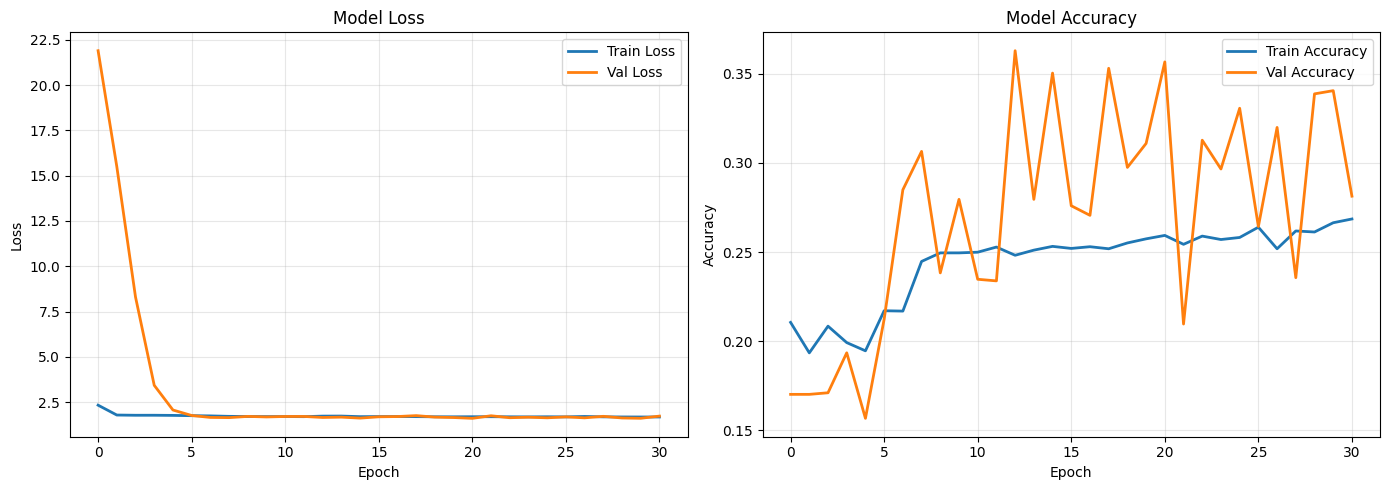

Saved training plot to results/training_history.png


In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Saved training plot to {RESULTS_PATH}/training_history.png")

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load best model
best_model = keras.models.load_model(f'{MODEL_PATH}/best_model.h5')

# Predict on test set
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred_classes)

print("="*70)
print("TEST SET EVALUATION")
print("="*70)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, 
                          target_names=le.classes_))

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
TEST SET EVALUATION
Test Accuracy: 0.3572 (35.72%)

Classification Report:
              precision    recall  f1-score   support

       anger       0.56      0.71      0.63       191
     disgust       0.50      0.01      0.02       191
        fear       0.28      0.09      0.14       190
       happy       0.39      0.40      0.39       191
     neutral       0.00      0.00      0.00       163
         sad       0.27      0.87      0.42       191

    accuracy                           0.36      1117
   macro avg       0.33      0.35      0.27      1117
weighted avg       0.34      0.36      0.27      1117



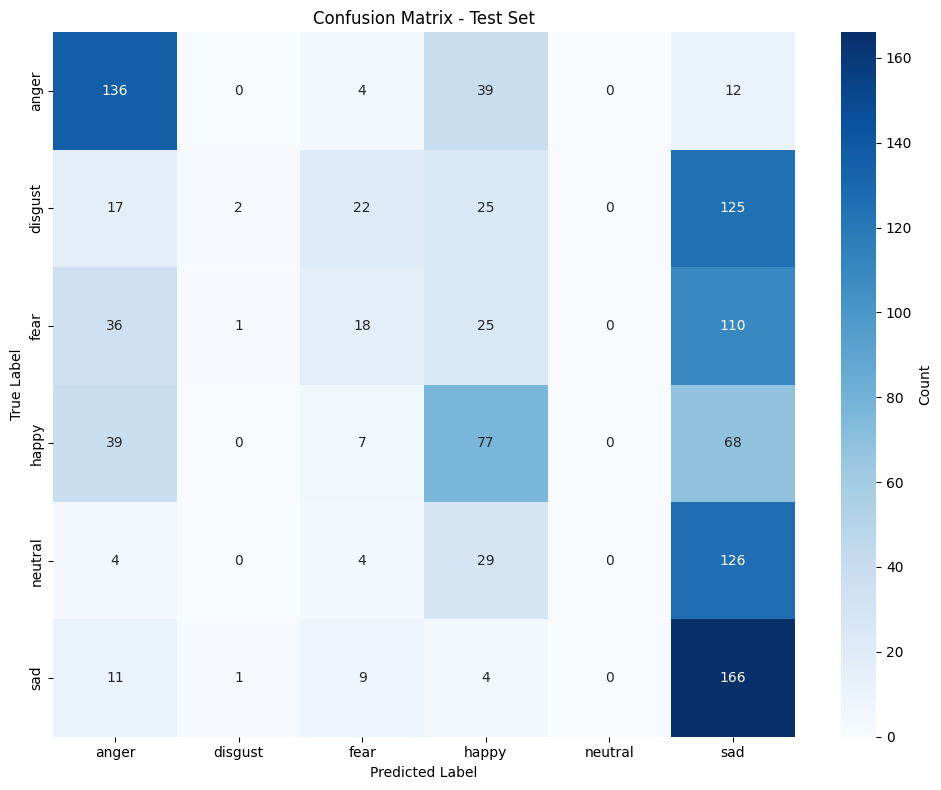

Saved confusion matrix to results/confusion_matrix.png


In [15]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Saved confusion matrix to {RESULTS_PATH}/confusion_matrix.png")

In [16]:
# Per-class metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_classes, labels=range(len(le.classes_))
)

results_df = pd.DataFrame({
    'Emotion': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("="*70)
print("PER-CLASS PERFORMANCE")
print("="*70)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv(f'{RESULTS_PATH}/per_class_metrics.csv', index=False)
print(f"\nSaved to {RESULTS_PATH}/per_class_metrics.csv")

PER-CLASS PERFORMANCE
Emotion  Precision   Recall  F1-Score  Support
  anger   0.559671 0.712042  0.626728      191
disgust   0.500000 0.010471  0.020513      191
   fear   0.281250 0.094737  0.141732      190
  happy   0.386935 0.403141  0.394872      191
neutral   0.000000 0.000000  0.000000      163
    sad   0.273476 0.869110  0.416040      191

Saved to results/per_class_metrics.csv


In [ ]:
summary_report = f"""
{'='*70}
MODEL TRAINING SUMMARY
{'='*70}

DATASET:
  Total samples: {len(X)}
  Training: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)
  Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)
  Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)

AUDIO PROPERTIES:
  Sample rate: {SAMPLE_RATE} Hz
  Mel bands: {N_MELS}
  Spectrogram shape: {X.shape}

MODEL ARCHITECTURE:
  Conv2D(32) → BatchNorm → MaxPool → Dropout(0.3)
  Conv2D(64) → BatchNorm → MaxPool → Dropout(0.3)
  Conv2D(128) → BatchNorm → MaxPool → Dropout(0.3)
  Flatten → Dense(256) → Dropout(0.5)
  Dense(128) → Dropout(0.3) → Dense(6) → Softmax

TRAINING:
  Optimizer: Adam (lr=0.001)
  Loss: Sparse Categorical Crossentropy
  Batch size: 32
  Max epochs: 50
  Early stopping: patience=10

RESULTS:
  Test Accuracy: {test_accuracy*100:.2f}%
  Best Model: {MODEL_PATH}/best_model.h5

SAVED FILES:
  models/best_model.h5 - Trained model
  models/label_encoder.npy - Class labels
  results/training_history.png - Training curves
  results/confusion_matrix.png - Confusion matrix
  results/per_class_metrics.csv - Per-class metrics

{'='*70}
TRAINING COMPLETE!
{'='*70}
"""

print(summary_report)

# Save report
with open(f'{RESULTS_PATH}/training_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(f"Saved report to {RESULTS_PATH}/training_summary.txt")


PHASE 3: MODEL TRAINING SUMMARY

DATASET:
  Total samples: 7442
  Training: 5209 (70.0%)
  Validation: 1116 (15.0%)
  Test: 1117 (15.0%)

AUDIO PROPERTIES:
  Sample rate: 22050 Hz
  Mel bands: 128
  Spectrogram shape: (7442, 128, 87)

MODEL ARCHITECTURE:
  Conv2D(32) → BatchNorm → MaxPool → Dropout(0.3)
  Conv2D(64) → BatchNorm → MaxPool → Dropout(0.3)
  Conv2D(128) → BatchNorm → MaxPool → Dropout(0.3)
  Flatten → Dense(256) → Dropout(0.5)
  Dense(128) → Dropout(0.3) → Dense(6) → Softmax

TRAINING:
  Optimizer: Adam (lr=0.001)
  Loss: Sparse Categorical Crossentropy
  Batch size: 32
  Max epochs: 50
  Early stopping: patience=10

RESULTS:
  Test Accuracy: 35.72%
  Best Model: models/best_model.h5

SAVED FILES:
  models/best_model.h5 - Trained model
  models/label_encoder.npy - Class labels
  results/training_history.png - Training curves
  results/confusion_matrix.png - Confusion matrix
  results/per_class_metrics.csv - Per-class metrics

TRAINING COMPLETE!

Saved report to results/tr